[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


File exists (long): True
File exists (short): True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



================ OBJECTIVE-1 ANALYSIS ================



/tmp/ipython-input-3630932829.py:94: UserWarning: PySoundFile failed. Trying audioread instead.
  speech, sr = librosa.load(audio_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded sample rate: 48000
Recognized Text:
 SHE JUDGED THE BLEUPEN PUT IT ON HER TABLE AND QUICKLY WHISPERED YES

Recognized Phonemes:
 SH IY1 JH AH1 JH D DH AH0 B L UW1 P AH0 N P UH1 T IH1 T AA1 N HH ER0 T EY1 B AH0 L AH0 N D K W IH1 K L IY0 W IH1 S P ER0 D Y EH1 S

--- Phoneme Analysis ---


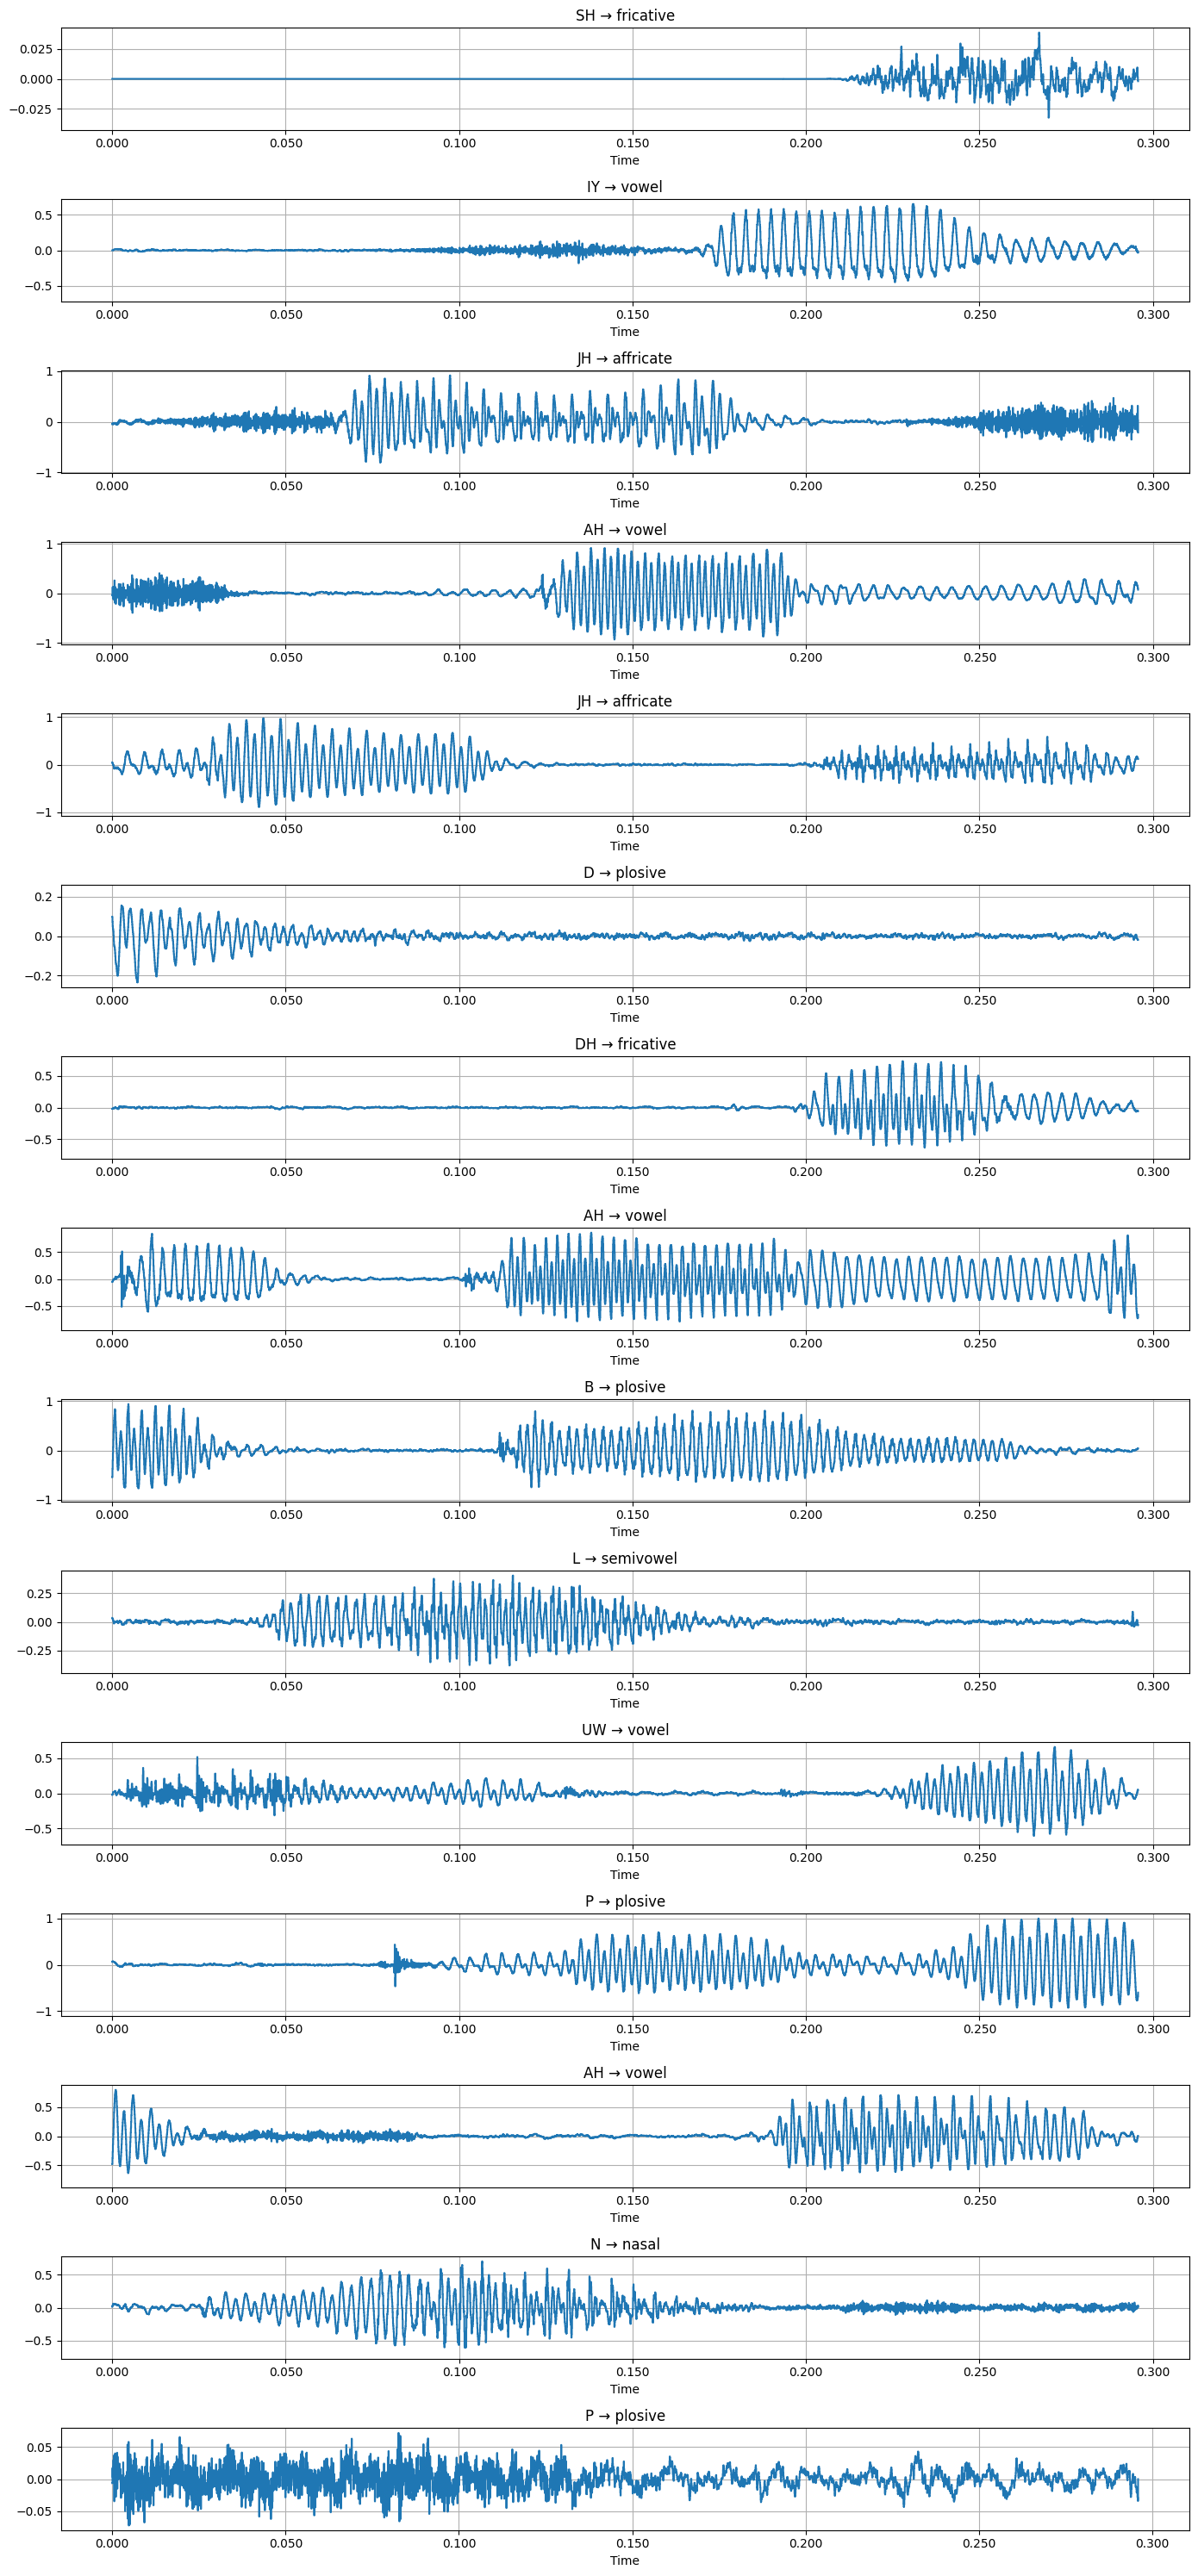

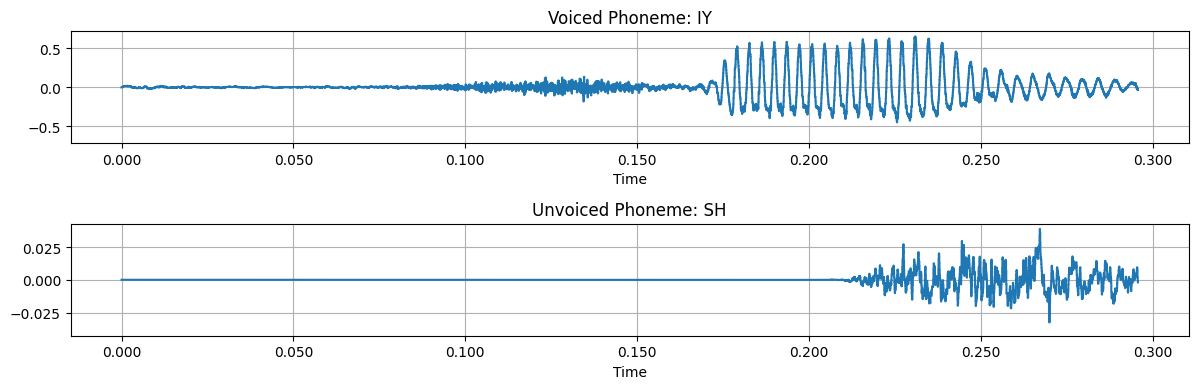


Fricatives found: ['SH', 'S', 'S']
Approximants found: ['Y']
Inference: Turbulent airflow (high Reynolds number)
Inference: Smooth laminar airflow (low Reynolds number)

================ OBJECTIVE-2 ANALYSIS ================



/tmp/ipython-input-3630932829.py:94: UserWarning: PySoundFile failed. Trying audioread instead.
  speech, sr = librosa.load(audio_path, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded sample rate: 48000
Recognized Text:
 SHE SEES YOU

Recognized Phonemes:
 SH IY1 S IY1 Z Y UW1

--- Phoneme Analysis ---


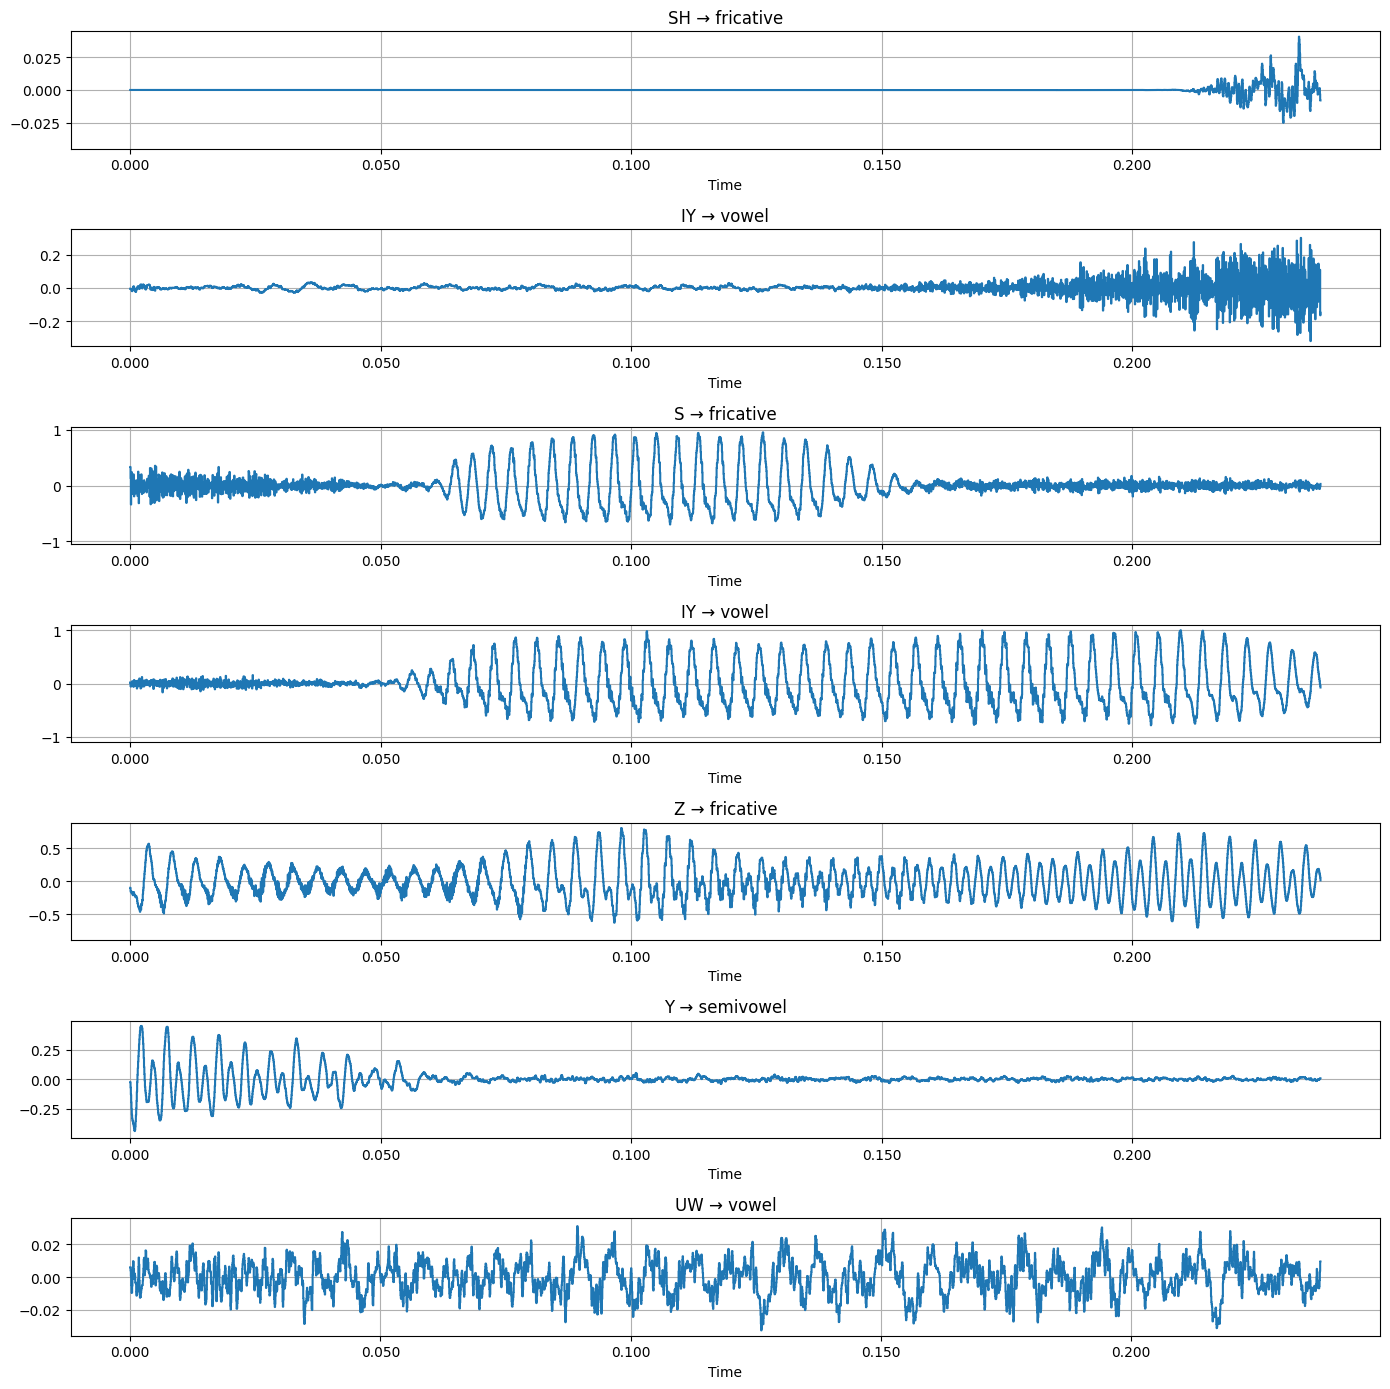

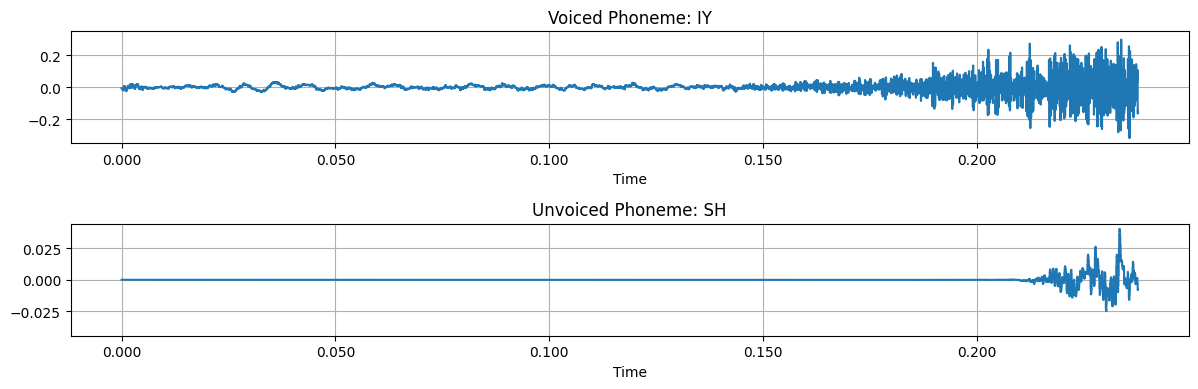


Fricatives found: ['SH', 'S', 'Z']
Approximants found: ['Y']
Inference: Turbulent airflow (high Reynolds number)
Inference: Smooth laminar airflow (low Reynolds number)


In [5]:
# =========================================
# LAB ASSIGNMENT 3 — COMPLETE PIPELINE (FINAL)
# =========================================

# !pip install torch torchaudio librosa transformers matplotlib g2p_en soundfile

import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import nltk
import os

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from g2p_en import G2p

# =========================================
# NLTK DOWNLOADS (run once)
# =========================================
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('cmudict')
# =========================================
# 🔴 CHANGE THESE PATHS
# =========================================
audio_path_long = "/content/long_audio.aac"
audio_path_short = "/content/short_audio.aac"

# =========================================
# ✅ SAFETY CHECK
# =========================================
print("File exists (long):", os.path.exists(audio_path_long))
print("File exists (short):", os.path.exists(audio_path_short))

# =========================================
# PHONEME CATEGORY MAP
# =========================================
phoneme_classes = {
    # vowels
    "AA":"vowel","AE":"vowel","AH":"vowel","AO":"vowel","AW":"diphthong",
    "AY":"diphthong","EH":"vowel","ER":"vowel","EY":"diphthong",
    "IH":"vowel","IY":"vowel","OW":"diphthong","OY":"diphthong","UH":"vowel","UW":"vowel",

    # plosives
    "P":"plosive","B":"plosive","T":"plosive","D":"plosive",
    "K":"plosive","G":"plosive",

    # fricatives
    "F":"fricative","V":"fricative","S":"fricative","Z":"fricative",
    "SH":"fricative","ZH":"fricative","TH":"fricative","DH":"fricative","HH":"fricative",

    # affricates
    "CH":"affricate","JH":"affricate",

    # semivowels / approximants
    "R":"semivowel","L":"semivowel","W":"semivowel","Y":"semivowel",

    # nasals
    "M":"nasal","N":"nasal","NG":"nasal"
}

voiced_set = {"AA","AE","AH","AO","EH","ER","IH","IY","OW","UH","UW",
              "B","D","G","Z","ZH","DH","JH","M","N","NG","L","R","W","Y","V"}

unvoiced_set = {"P","T","K","F","S","SH","TH","CH","HH"}

fricatives_target = {"S","SH","Z"}
approximants_target = {"Y"}  # /j/

# =========================================
# LOAD WAV2VEC2
# =========================================
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

g2p = G2p()

# =========================================
# 🔧 MAIN PROCESSING FUNCTION
# =========================================
def process_audio(audio_path, title_tag):

    print(f"\n================ {title_tag} ================\n")

    # =========================================
    # ✅ ROBUST AUDIO LOADING (FIXED)
    # =========================================
    speech, sr = librosa.load(audio_path, sr=None, mono=True)

    print("Loaded sample rate:", sr)

    # =========================================
    # RESAMPLE TO 16 kHz
    # =========================================
    target_sr = 16000
    if sr != target_sr:
        speech = librosa.resample(speech, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    # normalize (helps model)
    speech = speech / np.max(np.abs(speech) + 1e-9)

    # =========================================
    # SPEECH RECOGNITION
    # =========================================
    inputs = processor(
        speech,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        logits = model(inputs.input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)
    text = processor.decode(pred_ids[0])

    print("Recognized Text:\n", text)

    # =========================================
    # TEXT → PHONEMES
    # =========================================
    phonemes = g2p(text)
    phoneme_list = [p for p in phonemes if p != " "]
    clean_phonemes = [p.rstrip("012") for p in phoneme_list]

    print("\nRecognized Phonemes:\n", " ".join(phoneme_list))

    if len(clean_phonemes) == 0:
        print("⚠️ No phonemes detected — check recording quality")
        return

    # =========================================
    # PHONEME SEGMENTATION (approx)
    # =========================================
    num_parts = min(15, len(clean_phonemes))
    segment_length = len(speech)
    part_size = segment_length // num_parts

    voiced_example = None
    unvoiced_example = None

    print("\n--- Phoneme Analysis ---")

    plt.figure(figsize=(14, 2*num_parts))

    for i in range(num_parts):
        ph = clean_phonemes[i]

        start = i * part_size
        end = (i + 1) * part_size if i < num_parts - 1 else segment_length
        seg = speech[start:end]

        category = phoneme_classes.get(ph, "unknown")

        if ph in voiced_set and voiced_example is None:
            voiced_example = (ph, seg)

        if ph in unvoiced_set and unvoiced_example is None:
            unvoiced_example = (ph, seg)

        plt.subplot(num_parts, 1, i+1)
        librosa.display.waveshow(seg, sr=sr)
        plt.title(f"{ph} → {category}")
        plt.grid()

    plt.tight_layout()
    plt.show()

    # =========================================
    # VOICED vs UNVOICED COMPARISON
    # =========================================
    if voiced_example and unvoiced_example:
        plt.figure(figsize=(12,4))

        plt.subplot(2,1,1)
        librosa.display.waveshow(voiced_example[1], sr=sr)
        plt.title(f"Voiced Phoneme: {voiced_example[0]}")
        plt.grid()

        plt.subplot(2,1,2)
        librosa.display.waveshow(unvoiced_example[1], sr=sr)
        plt.title(f"Unvoiced Phoneme: {unvoiced_example[0]}")
        plt.grid()

        plt.tight_layout()
        plt.show()

    # =========================================
    # FRICATIVE vs APPROXIMANT
    # =========================================
    found_fricatives = [ph for ph in clean_phonemes if ph in fricatives_target]
    found_approximants = [ph for ph in clean_phonemes if ph in approximants_target]

    print("\nFricatives found:", found_fricatives)
    print("Approximants found:", found_approximants)

    if found_fricatives:
        print("Inference: Turbulent airflow (high Reynolds number)")

    if found_approximants:
        print("Inference: Smooth laminar airflow (low Reynolds number)")


# =========================================
# 🚀 RUN BOTH OBJECTIVES
# =========================================
process_audio(audio_path_long, "OBJECTIVE-1 ANALYSIS")
process_audio(audio_path_short, "OBJECTIVE-2 ANALYSIS")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


Original SR: 22050
Shape: torch.Size([1, 167226])
Final SR: 16000


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Recognized Text:
THE EXAMINATION AND TESTIMONY OF THE EXPERTS ENABLED THE COMMISSION TO CONCLUDE THAT FIVE SHOTS MAY HAVE BEEN FIRED

Recognized Phonemes:
DH AH0 IH0 G Z AE2 M AH0 N EY1 SH AH0 N AH0 N D T EH1 S T AH0 M OW2 N IY0 AH1 V DH AH0 EH1 K S P ER0 T S EH0 N EY1 B AH0 L D DH AH0 K AH0 M IH1 SH AH0 N T UW1 K AH0 N K L UW1 D DH AE1 T F AY1 V SH AA1 T S M EY1 HH AE1 V B IH1 N F AY1 ER0 D

Selected interval: 2.27s to 3.03s
Saved: extracted_phoneme.wav


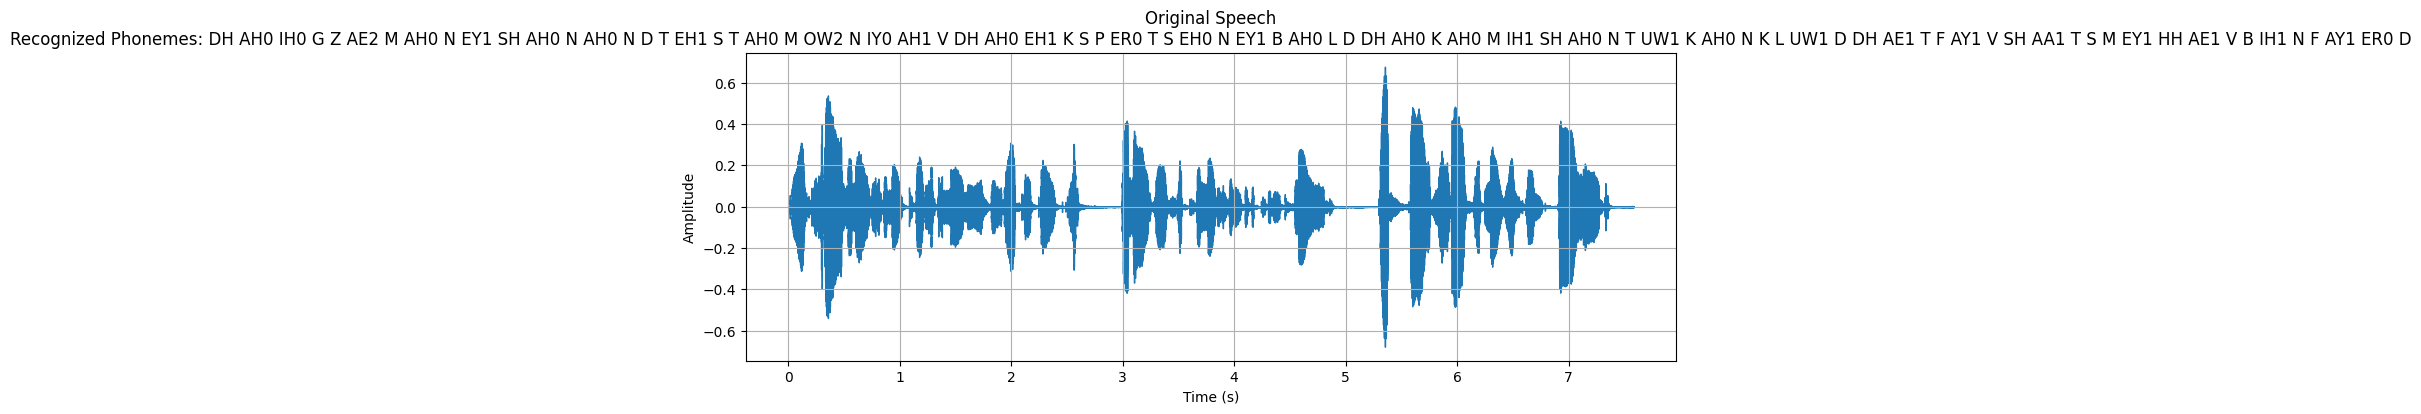

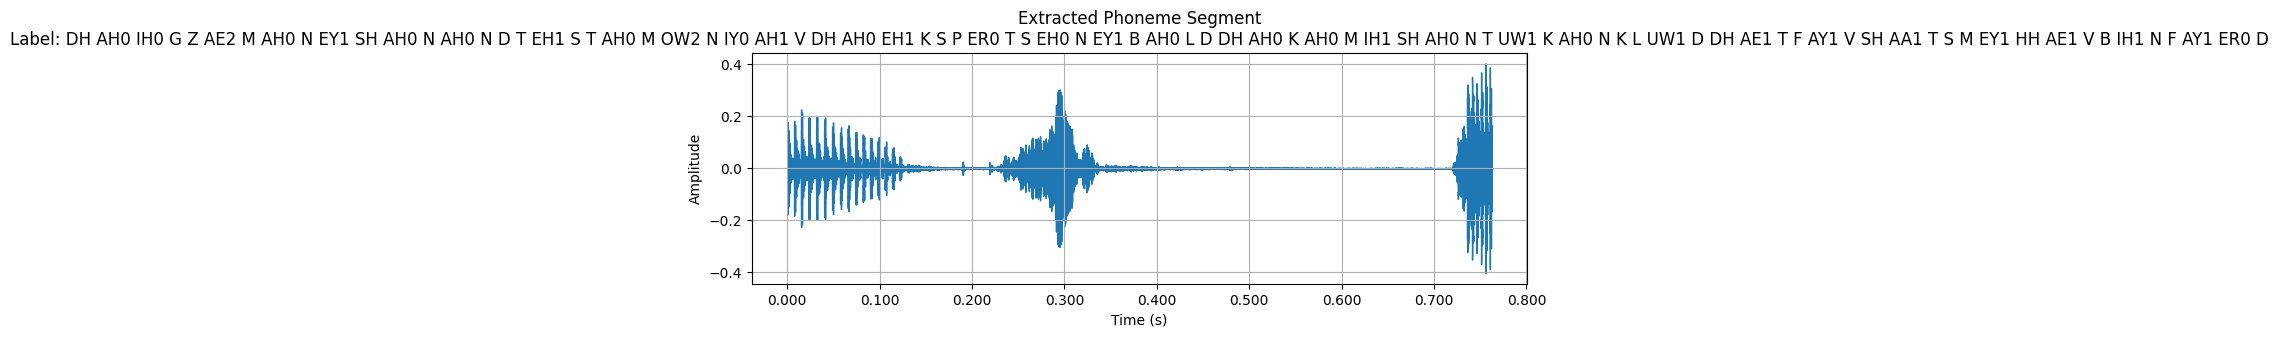


Inference: Voiced sound (likely vowel/voiced consonant)

--- First 10 Phoneme Waveforms ---


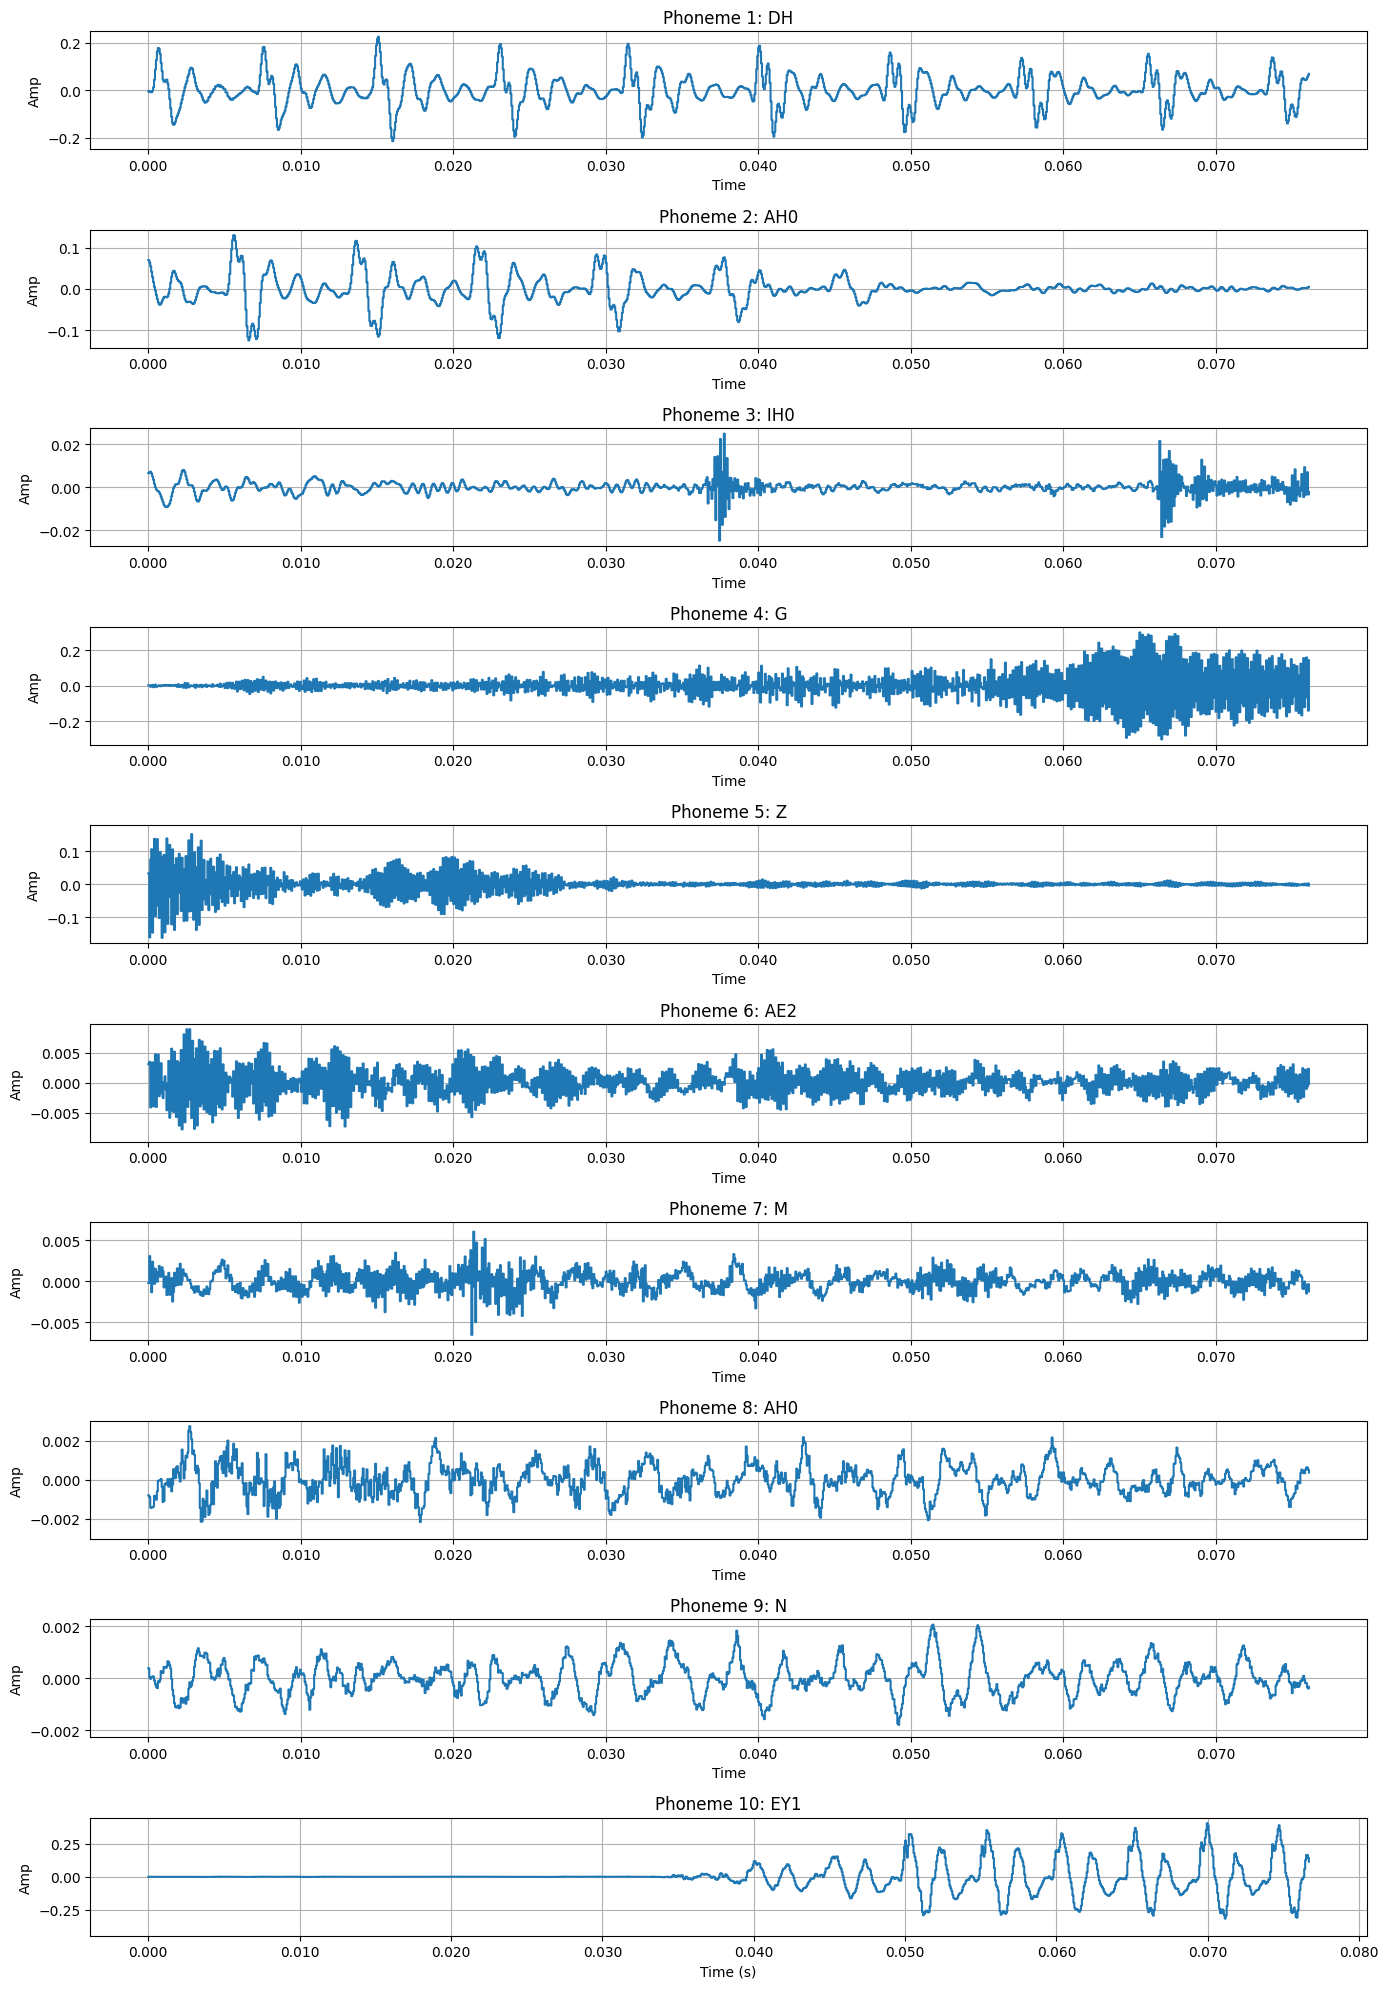

In [6]:
# =========================================
# LAB ASSIGNMENT 2 — FINAL VERSION
# =========================================

# (Run once in Colab if needed)
# !pip install torch torchaudio librosa transformers matplotlib g2p_en

# =========================================
# 1. IMPORTS
# =========================================
!pip install g2p_en
import nltk

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('cmudict')
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from g2p_en import G2p

# =========================================
# 2. LOAD LJ SPEECH AUDIO
# =========================================
audio_path = "/content/LJ037-0171.wav"  # 🔴 change if needed

waveform, sample_rate = torchaudio.load(audio_path)

# Validation
assert waveform is not None, "Audio not loaded"
assert sample_rate > 0, "Invalid sample rate"

print("Original SR:", sample_rate)
print("Shape:", waveform.shape)

# =========================================
# 3. PREPROCESS (MONO + 16 kHz)
# =========================================
# Convert to mono
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)

# Resample to 16 kHz
target_sr = 16000
if sample_rate != target_sr:
    resampler = torchaudio.transforms.Resample(sample_rate, target_sr)
    waveform = resampler(waveform)
    sample_rate = target_sr

assert sample_rate == 16000, "Resampling failed"

speech = waveform.squeeze().numpy()

print("Final SR:", sample_rate)

# =========================================
# 4. LOAD WAV2VEC2 MODEL
# =========================================
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

# =========================================
# 5. SPEECH RECOGNITION
# =========================================
inputs = processor(
    speech,
    sampling_rate=16000,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    logits = model(inputs.input_values).logits

pred_ids = torch.argmax(logits, dim=-1)
recognized_text = processor.decode(pred_ids[0])

print("\nRecognized Text:")
print(recognized_text)

# =========================================
# 6. TEXT → PHONEMES (ARPAbet)
# =========================================
g2p = G2p()
phonemes = g2p(recognized_text)

phoneme_list = [p for p in phonemes if p != " "]
phoneme_string = " ".join(phoneme_list)

print("\nRecognized Phonemes:")
print(phoneme_string)

# =========================================
# 7. ESTIMATE TIME INTERVAL
# =========================================
num_frames = logits.shape[1]
duration = len(speech) / sample_rate
time_per_frame = duration / num_frames

start_frame = int(num_frames * 0.30)
end_frame = int(num_frames * 0.40)

start_time = start_frame * time_per_frame
end_time = end_frame * time_per_frame

print(f"\nSelected interval: {start_time:.2f}s to {end_time:.2f}s")

# =========================================
# 8. EXTRACT PHONEME SEGMENT
# =========================================
start_sample = int(start_time * sample_rate)
end_sample = int(end_time * sample_rate)

phoneme_segment = speech[start_sample:end_sample]

assert len(phoneme_segment) > 0, "Extraction failed"

# =========================================
# 9. SAVE EXTRACTED PHONEME
# =========================================
output_file = "extracted_phoneme.wav"
sf.write(output_file, phoneme_segment, sample_rate)

print("Saved:", output_file)

# =========================================
# 10. PLOT ORIGINAL WAVEFORM
# =========================================
plt.figure(figsize=(12,4))
librosa.display.waveshow(speech, sr=sample_rate)
plt.title(f"Original Speech\nRecognized Phonemes: {phoneme_string}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# =========================================
# 11. PLOT EXTRACTED PHONEME
# =========================================
plt.figure(figsize=(10,3))
librosa.display.waveshow(phoneme_segment, sr=sample_rate)
plt.title(f"Extracted Phoneme Segment\nLabel: {phoneme_string}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# =========================================
# 12. INFER NATURE OF SOURCE
# =========================================
energy = np.sum(phoneme_segment ** 2)

if energy > 0.01:
    sound_type = "Voiced sound (likely vowel/voiced consonant)"
else:
    sound_type = "Unvoiced sound (likely fricative/silence)"

print("\nInference:", sound_type)
# =========================================
# EXTRA: FIRST 10 PHONEMES — SEPARATE PLOTS
# =========================================

print("\n--- First 10 Phoneme Waveforms ---")

# Take first 10 phonemes safely
first_10_phonemes = phoneme_list[:10]

# If segment is too small, handle safely
num_parts = len(first_10_phonemes)
segment_length = len(phoneme_segment)

if num_parts == 0:
    print("No phonemes available for plotting.")
else:
    part_size = segment_length // num_parts

    plt.figure(figsize=(14, 2*num_parts))

    for i, ph in enumerate(first_10_phonemes):
        start = i * part_size
        end = (i + 1) * part_size if i < num_parts - 1 else segment_length
        part_signal = phoneme_segment[start:end]

        plt.subplot(num_parts, 1, i + 1)
        librosa.display.waveshow(part_signal, sr=sample_rate)
        plt.title(f"Phoneme {i+1}: {ph}")
        plt.ylabel("Amp")
        plt.grid()

    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

In [4]:
!pip install g2p_en

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.4 MB/s eta 0:00:00
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=f385a777abc7e2314ec9a424bb1508d426399287d7eb5e15a1a322a8c521730a
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance
